# 결과 표시
실행 결과만 읽습니다. smoke 파일은 8월 pseudo-test이며 실제 9월 봉인 성능이 아닙니다. 미실행 산출물은 미실행으로 표시합니다.

In [1]:
from pathlib import Path
import os
from datetime import date
import json
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams['font.family'] = 'NanumSquare'
plt.rcParams['axes.unicode_minus'] = False
DATA = Path('../5. 자원 최적화 AI 데이터셋')
RESULTS = Path(os.environ.get('KAMP_RESULTS', os.environ.get('GMST_RESULTS', '../results')))
def table(name):
    path = RESULTS / name
    if path.exists():
        frame = pl.read_csv(path, infer_schema_length=None)
        display(frame)
        return frame
    print(f'{name}: 미실행 / 산출물 없음')
    return pl.DataFrame()

def metadata(name):
    path = RESULTS / name
    if path.exists():
        value = json.loads(path.read_text())
        display(value)
        return value
    print(f'{name}: 미실행 / 산출물 없음')
    return {}


## 제1장 데이터와 누수

{'n_rows_raw': 6168,
 'n_rows_15min': 24672,
 'n_days': 257,
 'zero_points': 74,
 'zero_by_day': {'2021-08-28': 26, '2021-08-29': 46, '2021-09-08': 2},
 'wind_null_hours': 3,
 'precip_null_hours': 1,
 'time_col_mismatch_rows': 48,
 'time_col_mismatch_dates': ['2021-07-13', '2021-07-15'],
 '공장인원_max_abs_err': 4.944070042256499e-09,
 '공장인원_n': 6151,
 '평균_match': 6168}

copy_kind,is_suspect,len
str,bool,u32
"""exact""",false,115
"""edited""",false,7
"""""",true,2
"""""",false,133


split,mae,n,n_days,n_splits,max_same_slot
str,f64,i64,i64,i64,i64
"""random_day_5fold""",15.536529,23064,241,5,96
"""loeo""",16.721078,23064,241,126,67


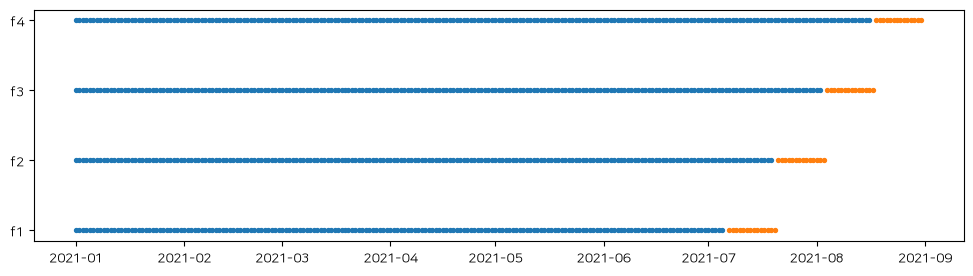

In [2]:
metadata('data_audit.json')
days = pl.read_csv(DATA / 'okm_cv_splits_2021.csv', try_parse_dates=True)
display(days.group_by('copy_kind', 'is_suspect').len())
table('leakage_gap.csv')
fig, ax = plt.subplots(figsize=(12, 3))
for j, fold in enumerate(('f1', 'f2', 'f3', 'f4')):
    for role, color in (('train', 'tab:blue'), ('val', 'tab:orange')):
        dates = days.filter(pl.col(fold) == role)['date']
        ax.scatter(dates, [j] * len(dates), s=8, color=color)
ax.set_yticks(range(4), ('f1', 'f2', 'f3', 'f4'))
plt.show()


## 제2장 후보 선택과 비교
동일 OOF에서 여러 후보를 비교한 CI는 탐색적입니다. 선택 후 우월성 보장으로 해석하지 않습니다. AWstar는 외부 기상 기여의 휴리스틱 상한입니다.

In [3]:
selection = metadata('selection.json')
if selection:
    candidates = pl.DataFrame(selection['candidates'])
    if (RESULTS / 'bootstrap.csv').exists():
        intervals = pl.read_csv(RESULTS / 'bootstrap.csv').filter(pl.col('comparison').str.ends_with('-B1') & pl.col('metric').is_in(['mae', 'brier_mean'])).with_columns(pl.col('comparison').str.strip_suffix('-B1').alias('model_id'))
        intervals = intervals.pivot(on='metric', index='model_id', values=['delta', 'ci_lo', 'ci_hi'])
        candidates = candidates.join(intervals, on='model_id', how='left')
    display(candidates)
    print(f"시도한 B4 후보 수: {selection['n_candidates_run']} / 4")
for name in ('bootstrap.csv', 'metrics.csv', 'backbone_tau.csv', 'ablation_status.csv', 'calibration_status.csv', 'io_lambda.csv', 'kan_grid.csv'):
    table(name)
metadata('risk_check.json')

metrics = pl.read_csv(RESULTS / 'metrics.csv') if (RESULTS / 'metrics.csv').exists() else pl.DataFrame()
if metrics.height:
    comparison = metrics.filter((pl.col('fold') == 'pooled') & (pl.col('variant') == 'main') & (pl.col('stratum') == 'all'))
    display(comparison.filter(pl.col('metric').is_in(['mae', 'rmse', 'crps', 'peak_mae', 'brier_platt_C90', 'auc_C90', 'bss_cond_C90', 'f1_C90_pstar'])).pivot(on='metric', index='model', values=['value', 'n']))
    display(comparison.filter(pl.col('metric') == 'n_events_C90').select('model', pl.col('value').alias('n_events_C90'), pl.col('n').alias('n_peak_days')))


{'mode': 'development',
 'frozen': True,
 'submitted_model': 'B4',
 'submitted_variant': 'main',
 'submitted': 'B4',
 'gate_met': False,
 'tried': ['main', 'H', 'IO', 'KAN'],
 'criteria': {'mae': [-2.947237666391931,
   -6.415235402894325,
   0.25315570852447844],
  'brier_mean': [0.0028902839502397055,
   -0.06632047507852026,
   0.06905387308802438]},
 'reported': {'crps': [-2.168209301516665,
   -4.824893851295429,
   0.20042514319839053]},
 'remaining_gap_to_b1': {'mae': [-2.947237666391931,
   -6.415235402894325,
   0.25315570852447844],
  'crps': [-2.168209301516665, -4.824893851295429, 0.20042514319839053],
  'brier_mean': [0.0028902839502397055,
   -0.06632047507852026,
   0.06905387308802438]},
 'candidates': [{'variant': 'main',
   'model_id': 'B4',
   'components': [],
   'status': 'run',
   'mae': 10.956429464299903,
   'brier_mean': 0.14974482003086675,
   'gate_met': False},
  {'variant': 'H',
   'model_id': 'B4-H',
   'components': ['H'],
   'status': 'run',
   'mae': 13

variant,model_id,components,status,mae,brier_mean,gate_met,delta_mae,delta_brier_mean,ci_lo_mae,ci_lo_brier_mean,ci_hi_mae,ci_hi_brier_mean
str,str,list[str],str,f64,f64,bool,f64,f64,f64,f64,f64,f64
"""main""","""B4""",[],"""run""",10.956429,0.149745,false,-2.947238,0.00289,-6.415235,-0.06632,0.253156,0.069054
"""H""","""B4-H""","[""H""]","""run""",13.233958,0.140379,false,-0.669709,-0.006476,-1.835551,-0.051833,0.434696,0.041842
"""IO""","""B4-IO""","[""IO""]","""run""",11.81329,0.188576,false,-2.090377,0.041722,-5.442315,-0.047523,1.106182,0.127672
"""KAN""","""B4-KAN""","[""KAN""]","""run""",11.381609,0.149327,false,-2.522058,0.002472,-6.006001,-0.073894,0.740141,0.073606


시도한 B4 후보 수: 4 / 4


comparison,metric,delta,ci_lo,ci_hi,dm_stat,dm_p,dm_method,n_days,n_valid_days,n_obs,lag1_correlation,serial_correlation,block7_ci_lo,block7_ci_hi,block7_status,exploratory
str,str,f64,f64,f64,f64,f64,str,i64,i64,i64,f64,bool,f64,f64,str,bool
"""B4-B1""","""mae""",-2.947238,-6.415235,0.253156,-1.753089,0.079587,"""DM-like normal, nonrobust vari…",53,53,5016,0.500152,true,-9.74342,2.373488,"""ok""",true
"""B4-B1""","""crps""",-2.168209,-4.824894,0.200425,-1.723791,0.084746,"""DM-like normal, nonrobust vari…",53,53,5016,0.542882,true,-7.29404,1.810569,"""ok""",true
"""B4-B1""","""brier_mean""",0.00289,-0.06632,0.069054,0.084775,0.93244,"""DM-like normal, nonrobust vari…",53,51,51,-0.038906,false,NaN,NaN,"""not_indicated""",true
"""AWstar-main""","""mae""",0.114729,-0.234475,0.433462,0.666415,0.505146,"""DM-like normal, nonrobust vari…",53,53,5016,0.180883,false,NaN,NaN,"""not_indicated""",true
"""AWstar-main""","""brier_mean""",-0.010098,-0.042217,0.01828,-0.652108,0.514331,"""DM-like normal, nonrobust vari…",53,51,51,0.261269,false,NaN,NaN,"""not_indicated""",true
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""B4-IO-B1""","""crps""",-1.321963,-3.871528,1.073296,-1.051124,0.293202,"""DM-like normal, nonrobust vari…",53,53,5016,0.593006,true,-6.515337,2.730356,"""ok""",true
"""B4-IO-B1""","""brier_mean""",0.041722,-0.047523,0.127672,0.957529,0.3383,"""DM-like normal, nonrobust vari…",53,51,51,0.110141,false,NaN,NaN,"""not_indicated""",true
"""B4-KAN-B1""","""mae""",-2.522058,-6.006001,0.740141,-1.473037,0.140741,"""DM-like normal, nonrobust vari…",53,53,5016,0.550589,true,-9.518597,3.026255,"""ok""",true


model,variant,fold,stratum,metric,value,n
str,str,str,str,str,f64,i64
"""B0""","""main""","""f1""","""all""","""mae""",8.547743,1152
"""B0""","""main""","""f1""","""all""","""rmse""",15.875137,1152
"""B0""","""main""","""f1""","""all""","""crps""",NaN,0
"""B0""","""main""","""f1""","""all""","""cov50""",NaN,0
"""B0""","""main""","""f1""","""all""","""cov80""",NaN,0
…,…,…,…,…,…,…
"""B4""","""KAN""","""pooled""","""nonop""","""precision_C90_pstar""",NaN,14
"""B4""","""KAN""","""pooled""","""nonop""","""recall_C90_pstar""",NaN,14
"""B4""","""KAN""","""pooled""","""nonop""","""f1_C90_pstar""",NaN,14


...

fold,lambda_io,nll_tune,n_tune,status
str,f64,f64,i64,str
"""f1""",0.0,3.585066,7,"""tuned"""
"""f1""",0.01,3.585849,7,"""tuned"""
"""f1""",0.1,3.229175,7,"""tuned"""
"""f1""",1.0,3.20521,7,"""tuned"""
"""f2""",0.0,3.242002,7,"""tuned"""
…,…,…,…,…
"""f3""",1.0,3.281099,7,"""tuned"""
"""f4""",0.0,1.94945,7,"""tuned"""
"""f4""",0.01,1.950384,7,"""tuned"""


fold,M,lambda_spl,nll_tune,n_tune,status
str,i64,f64,f64,i64,str
"""f1""",8,0.0,3.26627,7,"""tuned"""
"""f1""",8,0.01,3.27604,7,"""tuned"""
"""f1""",8,0.1,3.283535,7,"""tuned"""
"""f1""",8,1.0,3.287409,7,"""tuned"""
"""f1""",12,0.0,3.293162,7,"""tuned"""
…,…,…,…,…,…
"""f4""",12,1.0,2.218755,7,"""tuned"""
"""f4""",16,0.0,1.938891,7,"""tuned"""
"""f4""",16,0.01,1.99778,7,"""tuned"""


{'B0/main': {'C50': {'brier': 0.21748957431963672,
   'brier_climcond': 0.13241040317528027,
   'auc': 0.7709677419354839,
   'bss_cond': -0.6425414401293803,
   'n_events': 31,
   'n_days': 51,
   'pass': False},
  'C75': {'brier': 0.3409567348646739,
   'brier_climcond': 0.235325154095457,
   'auc': 0.6365079365079365,
   'bss_cond': -0.4488750094533822,
   'n_events': 21,
   'n_days': 51,
   'pass': False},
  'C90': {'brier': 0.2828850673321685,
   'brier_climcond': 0.20041775996198943,
   'auc': 0.5040485829959515,
   'bss_cond': -0.4114770436802584,
   'n_events': 13,
   'n_days': 51,
   'pass': False},
  'discrimination_missing': True},
 'B0p/main': {'C50': {'brier': 0.0615427907655615,
   'brier_climcond': 0.13241040317528027,
   'auc': 0.9669354838709677,
   'bss_cond': 0.5352118165209927,
   'n_events': 31,
   'n_days': 51,
   'pass': True},
  'C75': {'brier': 0.255380667115099,
   'brier_climcond': 0.235325154095457,
   'auc': 0.7507936507936508,
   'bss_cond': -0.08522468877

model,value_mae,value_rmse,value_crps,value_peak_mae,value_auc_C90,value_brier_platt_C90,value_bss_cond_C90,value_f1_C90_pstar,n_mae,n_rmse,n_crps,n_peak_mae,n_auc_C90,n_brier_platt_C90,n_bss_cond_C90,n_f1_C90_pstar
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64
"""B0""",26.840311,52.618275,NaN,42.215686,0.677126,0.282885,-0.411477,0.125,5016,5016,0,51,51,51,51,51
"""B0p""",13.720096,25.744396,NaN,6.490196,0.845142,0.151678,0.24319,0.421053,5016,5016,0,51,51,51,51,51
"""BB""",13.059019,19.62565,NaN,15.285573,0.5,0.243776,-0.216341,0.4,5016,5016,0,51,51,51,51,51
"""B1""",13.903667,19.519222,10.515773,23.633517,0.6417,0.152385,0.239664,0.466667,5016,5016,5016,51,51,51,51,51
"""B2""",12.474671,18.022194,9.452716,12.010853,0.827935,0.224244,-0.118884,0.577778,5016,5016,5016,51,51,51,51,51
"""B3""",9.944506,15.225583,7.674885,9.69396,0.939271,0.257333,-0.283982,0.619048,5016,5016,5016,51,51,51,51,51
"""B4""",10.956429,16.879885,8.347564,11.840764,0.82085,0.168498,0.159268,0.666667,5016,5016,5016,51,51,51,51,51


model,n_events_C90,n_peak_days
str,f64,i64
"""B0""",13.0,51
"""B0p""",13.0,51
"""BB""",13.0,51
"""B1""",13.0,51
"""B2""",13.0,51
"""B3""",13.0,51
"""B4""",13.0,51


## 확률 보정 신뢰도

fold,variant,model,date,usable_peak,n_obs,M_true,M_hat_median,M_hat_mean,peak_slot_true,peak_time_mode,C50,C75,C90,risk_raw_C50,risk_raw_C75,risk_raw_C90,risk_platt_C50,risk_platt_C75,risk_platt_C90,event_C50,event_C75,event_C90,nll,n_nll,calibration_status_platt_C50,calibration_status_platt_C75,calibration_status_platt_C90,n_cal_platt_C50,n_cal_platt_C75,n_cal_platt_C90,isotonic_status
str,str,str,str,bool,i64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,str,str,str,i64,i64,i64,str
"""f1""","""main""","""B0""","""2021.07.07""",true,96,203.0,193.0,193.0,35,35,181.0,189.5,198.0,1.0,1.0,0.0,0.666698,0.001975,0.001975,1.0,1.0,1.0,null,null,"""ok""","""ok""","""ok""",7,7,7,"""not_run"""
"""f1""","""main""","""B0""","""2021.07.08""",true,96,201.0,206.0,206.0,43,55,181.0,189.5,198.0,1.0,1.0,1.0,0.666698,0.001975,0.001975,1.0,1.0,1.0,null,null,"""ok""","""ok""","""ok""",7,7,7,"""not_run"""
"""f1""","""main""","""B0""","""2021.07.09""",true,96,192.0,187.0,187.0,59,36,181.0,189.5,198.0,1.0,0.0,0.0,0.666698,0.16699,0.16699,1.0,1.0,0.0,null,null,"""ok""","""ok""","""ok""",7,7,7,"""not_run"""
"""f1""","""main""","""B0""","""2021.07.10""",true,96,106.0,112.0,112.0,15,16,181.0,189.5,198.0,0.0,0.0,0.0,0.250027,0.16699,0.16699,0.0,0.0,0.0,null,null,"""ok""","""ok""","""ok""",7,7,7,"""not_run"""
"""f1""","""main""","""B0""","""2021.07.11""",true,96,28.0,28.0,28.0,46,33,181.0,189.5,198.0,0.0,0.0,0.0,0.250027,0.16699,0.16699,0.0,0.0,0.0,null,null,"""ok""","""ok""","""ok""",7,7,7,"""not_run"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""f4""","""KAN""","""B4""","""2021.08.27""",true,96,190.0,208.5121,210.065041,34,34,185.0,198.0,211.0,0.9915,0.8105,0.4315,0.999999,0.98806,0.262404,1.0,0.0,0.0,3.627508,96,"""ok""","""ok""","""ok""",7,7,7,"""not_run"""
"""f4""","""KAN""","""B4""","""2021.08.28""",false,70,119.0,119.933121,123.850477,9,8,185.0,198.0,211.0,0.001,0.0,0.0,2.7580e-8,3.3347e-56,3.3347e-56,NaN,NaN,NaN,3.524165,70,"""ok""","""ok""","""ok""",7,7,7,"""not_run"""
"""f4""","""KAN""","""B4""","""2021.08.29""",false,50,41.0,28.489972,28.93543,46,0,185.0,198.0,211.0,0.0,0.0,0.0,6.2933e-10,3.3347e-56,3.3347e-56,NaN,NaN,NaN,2.02649,50,"""ok""","""ok""","""ok""",7,7,7,"""not_run"""


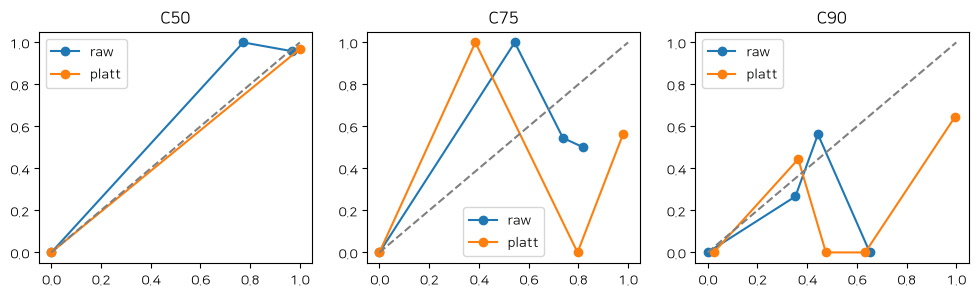

In [4]:
oof = table('oof_days.csv')
if oof.height:
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    for ax, c in zip(axes, ('C50', 'C75', 'C90')):
        for kind in ('raw', 'platt'):
            p = f'risk_{kind}_{c}'
            curve = oof.filter((pl.col('model') == 'B4') & (pl.col('variant') == selection.get('submitted_variant', 'main')) & pl.col('usable_peak')).with_columns((pl.col(p) * 5).floor().clip(0,4).alias('bin')).group_by('bin').agg(pl.col(p).mean(), pl.col(f'event_{c}').mean()).sort('bin')
            ax.plot(curve[p], curve[f'event_{c}'], 'o-', label=kind)
        ax.plot([0,1],[0,1], '--', color='grey')
        ax.set_title(c)
        ax.legend()
    plt.show()


## 제3장 조건별 오류와 FN/FP

model,variant,condition,bin,n,mae,rmse
str,str,str,str,i64,f64,f64
"""B1""","""main""","""daytype""","""sat""",742,6.216882,10.911995
"""B1""","""main""","""daytype""","""sun""",722,3.206857,4.97117
"""B1""","""main""","""daytype""","""wk""",3552,17.683704,26.369316
"""B1""","""main""","""holiday_adjacent""","""next_nonop""",646,5.834596,11.116034
"""B1""","""main""","""holiday_adjacent""","""other""",2930,13.534443,20.532662
…,…,…,…,…,…,…
"""B4""","""main""","""state_smooth_transition""","""stable""",4479,10.967832,16.964392
"""B4""","""main""","""state_smooth_transition""","""transition""",485,11.301338,16.358843
"""B4""","""main""","""temperature""","""q2""",196,11.841217,17.505891


model,variant,C,p_star_kind,date,kind,daytype,op_prev,op_next,prev_day_max,temp_mean,prod_sum,risk_cal,M_true
str,str,str,str,str,str,str,i64,i64,f64,f64,f64,f64,f64
"""B4""","""main""","""C50""","""0.5""","""2021.07.07""","""TP""","""wk""",1,1,193.0,23.7,19407.0,0.999677,203.0
"""B4""","""main""","""C50""","""0.5""","""2021.07.08""","""TP""","""wk""",1,1,203.0,23.25,19519.0,0.999755,201.0
"""B4""","""main""","""C50""","""0.5""","""2021.07.09""","""TP""","""wk""",1,1,201.0,22.8,16527.0,0.999683,192.0
"""B4""","""main""","""C50""","""0.5""","""2021.07.10""","""TN""","""sat""",1,0,192.0,25.170833,487.0,0.000003,106.0
"""B4""","""main""","""C50""","""0.5""","""2021.07.11""","""TN""","""sun""",1,1,106.0,26.466667,0.0,1.3825e-10,28.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""B1""","""main""","""C90""","""pstar""","""2021.08.25""","""FP""","""wk""",1,1,201.0,25.2,22076.0,0.143333,189.0
"""B1""","""main""","""C90""","""pstar""","""2021.08.26""","""FP""","""wk""",1,1,189.0,27.133333,20064.0,0.1446,202.0
"""B1""","""main""","""C90""","""pstar""","""2021.08.27""","""TN""","""wk""",1,1,202.0,25.8,25769.0,0.142549,190.0


model,variant,C,p_star_kind,kind,condition,bin,n,share,n_all,share_all
str,str,str,str,str,str,str,i64,f64,i64,f64
"""B4""","""main""","""C50""","""0.5""","""all""","""daytype""","""sat""",7,0.137255,7,0.137255
"""B4""","""main""","""C50""","""0.5""","""all""","""daytype""","""sun""",7,0.137255,7,0.137255
"""B4""","""main""","""C50""","""0.5""","""all""","""daytype""","""wk""",37,0.72549,37,0.72549
"""B4""","""main""","""C50""","""0.5""","""FN""","""daytype""","""sat""",0,NaN,7,0.137255
"""B4""","""main""","""C50""","""0.5""","""FN""","""daytype""","""sun""",0,NaN,7,0.137255
…,…,…,…,…,…,…,…,…,…,…
"""B1""","""main""","""C90""","""pstar""","""FN""","""prod_sum""","""q3""",4,0.666667,13,0.254902
"""B1""","""main""","""C90""","""pstar""","""FN""","""prod_sum""","""q4""",1,0.166667,13,0.254902
"""B1""","""main""","""C90""","""pstar""","""FP""","""prod_sum""","""q2""",4,0.4,25,0.490196


op,daytype,hour,from_state,p_to_high
i64,str,i64,i64,f64
0,"""wk""",0,1,0.025976
0,"""wk""",0,2,0.040577
0,"""wk""",0,3,0.694306
0,"""wk""",1,1,0.018402
0,"""wk""",1,2,0.122001
…,…,…,…,…
1,"""sun""",22,2,0.00285
1,"""sun""",22,3,0.623589
1,"""sun""",23,1,0.012028


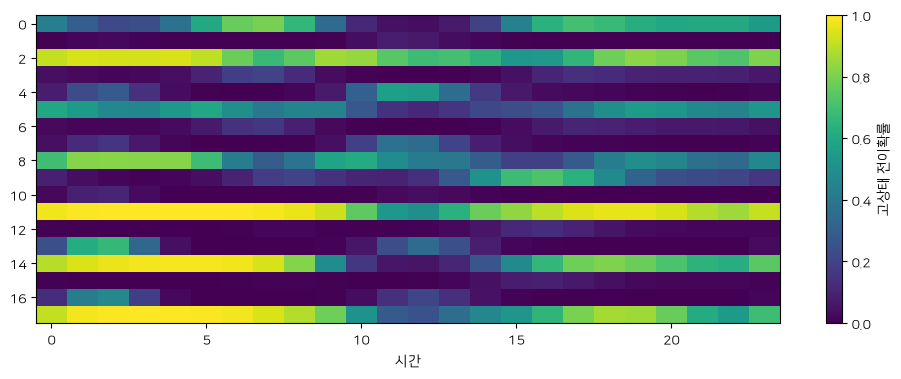

In [5]:
for name in ('error_by_condition.csv', 'fn_fp_days.csv', 'fn_fp_summary.csv', 'hmm_transitions.csv'):
    table(name)
transitions = pl.read_csv(RESULTS / 'hmm_transitions.csv') if (RESULTS / 'hmm_transitions.csv').exists() else pl.DataFrame()
if transitions.height:
    heat = transitions.pivot(on='hour', index=['op', 'daytype', 'from_state'], values='p_to_high').sort('op', 'daytype', 'from_state')
    plt.figure(figsize=(12, 4))
    plt.imshow(heat.select([str(h) for h in range(24)]).to_numpy(), aspect='auto', vmin=0, vmax=1)
    plt.colorbar(label='고상태 전이확률')
    plt.xlabel('시간')
    plt.show()


## 제4장 생산계획 시나리오 — 상한
월 기본요금과 일 전력량요금 성분은 분리합니다. 래칫 바닥 222(07-19 11:15) → 7–8월 기본요금 절감 ≈ 0, 주 수단은 TOU 전력량요금 이동. 원 단위는 15분 평균 kW 가정입니다.

In [6]:
monthly = table('scenarios_month.csv')
if monthly.height:
    display(monthly.select('month', 'scenario', 'rate', 'd_demand_won', 'd_energy_won', 'd_total_won', 'd_total_pct'))
table('scenarios.csv')

month,scenario,rate,n_days,P_floor,E_P_app_base,E_P_app_scn,d_demand_won,d_energy_won,d_kwh,d_total_won,d_total_pct,C_change,eta_star,risk_ok_all
i64,str,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
7,"""baseline""",0.0,8,222.0,222.050076,222.050076,0.0,0.0,0.0,0.0,0.0,0.0,NaN,true
7,"""shift_peak""",0.1,8,222.0,222.050076,222.050076,0.0,-33.88016,-0.354844,-33.88016,-0.000725,0.04221,802.665428,false
7,"""shift_peak""",0.2,8,222.0,222.050076,222.050076,0.0,-63.415501,-0.418819,-63.415501,-0.001357,0.084419,751.198202,false
7,"""shift_peak""",0.3,8,222.0,222.050076,222.050076,0.0,-124.462571,-0.801846,-124.462571,-0.002663,0.126629,982.893866,false
7,"""stagger_start""",0.1,8,222.0,222.050076,222.050076,0.0,36.4211,0.438135,36.4211,0.000779,0.006456,-5641.616055,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
8,"""avoid_high""",0.2,19,222.0,223.378861,223.378861,0.0,0.0,0.0,0.0,0.0,0.0,NaN,true
8,"""avoid_high""",0.3,19,222.0,223.378861,223.378861,0.0,0.0,0.0,0.0,0.0,0.0,NaN,true
8,"""ease_peak""",0.1,19,222.0,223.378861,223.379775,7.607412,110.725174,0.696941,118.332586,0.001406,0.010164,-11642.373261,false


month,scenario,rate,d_demand_won,d_energy_won,d_total_won,d_total_pct
i64,str,f64,f64,f64,f64,f64
7,"""baseline""",0.0,0.0,0.0,0.0,0.0
7,"""shift_peak""",0.1,0.0,-33.88016,-33.88016,-0.000725
7,"""shift_peak""",0.2,0.0,-63.415501,-63.415501,-0.001357
7,"""shift_peak""",0.3,0.0,-124.462571,-124.462571,-0.002663
7,"""stagger_start""",0.1,0.0,36.4211,36.4211,0.000779
…,…,…,…,…,…,…
8,"""avoid_high""",0.2,0.0,0.0,0.0,0.0
8,"""avoid_high""",0.3,0.0,0.0,0.0,0.0
8,"""ease_peak""",0.1,7.607412,110.725174,118.332586,0.001406


fold,date,scenario,rate,E_M,M_median,risk_C50,risk_C75,risk_C90,risk_ok,peak_time_mode,C_change,d_energy_won,eta_star
str,str,str,f64,f64,f64,f64,f64,f64,bool,i64,f64,f64,f64
"""f2""","""2021.07.21""","""baseline""",0.0,199.699018,199.166664,1.0,0.8585,0.434,true,46,0.0,0.0,NaN
"""f2""","""2021.07.21""","""shift_peak""",0.1,199.697316,199.166664,1.0,0.859,0.4335,true,46,0.050013,-15.335606,306.633348
"""f2""","""2021.07.21""","""shift_peak""",0.2,199.687764,199.165512,1.0,0.859,0.4325,true,46,0.100026,-20.759848,207.545158
"""f2""","""2021.07.21""","""shift_peak""",0.3,199.686244,199.16127,1.0,0.859,0.432,true,46,0.150039,-37.7137,251.360085
"""f2""","""2021.07.21""","""stagger_start""",0.1,199.699018,199.166664,1.0,0.8585,0.434,true,46,0.002872,0.370833,-129.101707
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""f4""","""2021.08.31""","""avoid_high""",0.2,211.128629,210.82341,1.0,0.9685,0.493,true,34,0.0,0.0,NaN
"""f4""","""2021.08.31""","""avoid_high""",0.3,211.128629,210.82341,1.0,0.9685,0.493,true,34,0.0,0.0,NaN
"""f4""","""2021.08.31""","""ease_peak""",0.1,211.091787,210.808479,1.0,0.968,0.492,true,34,0.0097,-0.556002,57.318779


fold,date,scenario,rate,E_M,M_median,risk_C50,risk_C75,risk_C90,risk_ok,peak_time_mode,C_change,d_energy_won,eta_star
str,str,str,f64,f64,f64,f64,f64,f64,bool,i64,f64,f64,f64
"""f2""","""2021.07.21""","""baseline""",0.0,199.699018,199.166664,1.0,0.8585,0.434,true,46,0.0,0.0,NaN
"""f2""","""2021.07.21""","""shift_peak""",0.1,199.697316,199.166664,1.0,0.859,0.4335,true,46,0.050013,-15.335606,306.633348
"""f2""","""2021.07.21""","""shift_peak""",0.2,199.687764,199.165512,1.0,0.859,0.4325,true,46,0.100026,-20.759848,207.545158
"""f2""","""2021.07.21""","""shift_peak""",0.3,199.686244,199.16127,1.0,0.859,0.432,true,46,0.150039,-37.7137,251.360085
"""f2""","""2021.07.21""","""stagger_start""",0.1,199.699018,199.166664,1.0,0.8585,0.434,true,46,0.002872,0.370833,-129.101707
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""f4""","""2021.08.31""","""avoid_high""",0.2,211.128629,210.82341,1.0,0.9685,0.493,true,34,0.0,0.0,NaN
"""f4""","""2021.08.31""","""avoid_high""",0.3,211.128629,210.82341,1.0,0.9685,0.493,true,34,0.0,0.0,NaN
"""f4""","""2021.08.31""","""ease_peak""",0.1,211.091787,210.808479,1.0,0.968,0.492,true,34,0.0097,-0.556002,57.318779


## 제5장 상태 안정성

In [7]:
table('state_stability.csv')

seed_a,seed_b,occ_maxdiff,delta_maxdiff,same_order,same_conclusion,agreement
i64,i64,f64,f64,bool,bool,f64
0,1,0.156859,2.875147,true,false,0.636285
0,2,0.115831,5.577384,true,false,0.759549
1,2,0.25186,2.702236,true,false,0.574653


seed_a,seed_b,occ_maxdiff,delta_maxdiff,same_order,same_conclusion,agreement
i64,i64,f64,f64,bool,bool,f64
0,1,0.156859,2.875147,true,false,0.636285
0,2,0.115831,5.577384,true,false,0.759549
1,2,0.25186,2.702236,true,false,0.574653


## 제6장 제출 형식

datetime,track,model,y_mean,y_median,q05,q10,q15,q20,q25,q30,q35,q40,q45,q50,q55,q60,q65,q70,q75,q80,q85,q90,q95,M_hat_median,M_hat_mean,peak_time_mode,risk_C50,risk_C75,risk_C90,C50,C75,C90
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64
"""2021.09.01 00:00:00""","""MAIN""","""B4""",76.818361,76.875645,64.304633,67.514,69.570604,70.932652,72.146893,73.291476,74.265927,75.140048,75.986151,76.875645,77.903398,78.822682,79.706387,80.598594,81.589144,82.880032,84.311507,85.794536,88.481501,198.689354,201.933559,"""08:30""",0.963848,0.555768,0.239928,186.5,198.0,210.7
"""2021.09.01 00:15:00""","""MAIN""","""B4""",73.74204,74.020454,56.764724,61.398921,64.010947,65.768462,67.676281,69.136013,70.386192,71.395851,72.740774,74.020454,75.266756,76.645529,77.879671,79.021405,80.504946,82.08298,84.054718,86.14463,88.914302,198.689354,201.933559,"""08:30""",0.963848,0.555768,0.239928,186.5,198.0,210.7
"""2021.09.01 00:30:00""","""MAIN""","""B4""",72.477622,72.47123,53.093773,57.729165,60.495942,63.147423,64.971146,66.640596,68.106537,69.468318,70.920123,72.47123,74.034325,75.393416,76.75259,78.502663,80.021505,82.50649,84.853164,87.766718,91.861707,198.689354,201.933559,"""08:30""",0.963848,0.555768,0.239928,186.5,198.0,210.7
"""2021.09.01 00:45:00""","""MAIN""","""B4""",70.997255,70.911194,50.419157,55.45632,58.231961,60.347131,62.299541,64.219019,66.015996,67.786334,69.270374,70.911194,72.673339,74.210832,76.012758,77.843228,79.693544,82.083292,84.606034,87.382604,91.951064,198.689354,201.933559,"""08:30""",0.963848,0.555768,0.239928,186.5,198.0,210.7
"""2021.09.01 01:00:00""","""MAIN""","""B4""",88.687376,88.511791,67.13493,71.63858,74.544048,77.016722,79.583015,81.56327,83.608922,85.358011,86.724326,88.511791,89.898196,91.761977,93.605657,95.718755,97.758474,100.537099,103.341777,106.717265,111.486043,198.689354,201.933559,"""08:30""",0.963848,0.555768,0.239928,186.5,198.0,210.7
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2021.09.14 22:45:00""","""MAIN""","""B4""",114.125777,112.328568,90.353217,96.172102,99.138819,101.871609,103.913654,105.867767,107.476025,109.04978,110.879895,112.328568,114.354832,116.443503,118.410506,120.821333,123.845116,127.274077,130.673219,136.092368,143.398636,198.401955,201.583089,"""08:30""",0.963848,0.550963,0.231414,186.5,198.0,210.7
"""2021.09.14 23:00:00""","""MAIN""","""B4""",113.148977,111.609364,89.145943,94.765966,98.560459,100.685364,102.856203,104.873914,106.603231,108.496895,110.045115,111.609364,113.319132,115.372383,117.571689,119.988261,122.882666,126.322198,129.876083,135.673912,142.341396,198.401955,201.583089,"""08:30""",0.963848,0.550963,0.231414,186.5,198.0,210.7
"""2021.09.14 23:15:00""","""MAIN""","""B4""",112.5171,110.784393,87.813693,94.463023,97.676868,99.854134,102.136572,104.070193,105.429327,106.992998,108.953283,110.784393,112.888601,115.09527,117.469313,120.058468,123.136013,126.457074,129.821921,134.685431,141.690389,198.401955,201.583089,"""08:30""",0.963848,0.550963,0.231414,186.5,198.0,210.7


datetime,is_missing
str,bool
"""2021.09.01 00:00:00""",false
"""2021.09.01 00:15:00""",false
"""2021.09.01 00:30:00""",false
"""2021.09.01 00:45:00""",false
"""2021.09.01 01:00:00""",false
…,…
"""2021.09.14 22:45:00""",false
"""2021.09.14 23:00:00""",false
"""2021.09.14 23:15:00""",false


고정 선택 후 실제 봉인 평가


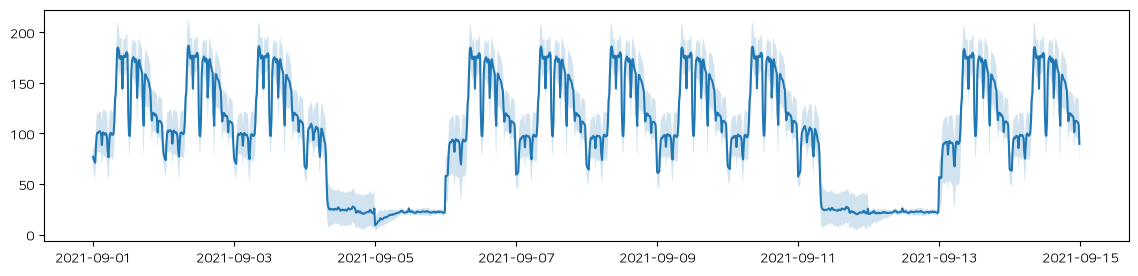

사후 평가 결측점: 2


In [8]:
predictions = table('test_predictions.csv')
mask = table('eval_mask.csv')
if predictions.height:
    print('SMOKE pseudo-test — 실제 봉인 평가 아님' if predictions['datetime'][0] < '2021.09.01' else '고정 선택 후 실제 봉인 평가')
    x = predictions['datetime'].str.strptime(pl.Datetime, '%Y.%m.%d %H:%M:%S')
    plt.figure(figsize=(14, 3))
    plt.plot(x, predictions['y_median'])
    plt.fill_between(x, predictions['q10'], predictions['q90'], alpha=.2)
    plt.show()
if mask.height:
    print('사후 평가 결측점:', mask['is_missing'].sum())
